- **Dataset**

Podaci su preuzeti sa [AAVSO](https://www.aavso.org/bob-nelsons-o-c-files) baze podataka (American Association of Variable Star Observers). Odavde su preuzeti samo podaci za sisteme kod kojih potencijalno postoji treći pratilac. Postoji kolona u podacima koja ima vrednosti yes, no i maybe. Takođe, na toj bazi mogu da se vide i izgledi OC dijagrama, tako da je odrađena i vizuelna inspekcija, ako postoji sinusni trend onda postoji i mogućnost da nastaje zbog postojanja trećeg pratioca).

Preuzeti podaci se nalaze u.csv fajlovima u folderu Podaci u ovom repozitorijumu.

Periodi su preuzeti sa [O-C gateway baze](https://var.astro.cz/en/Stars/18125) podataka i nalaze se u tabeli Periodi.csv

- **Veličina dataset-a**: folder Podaci, 3.7 MB

- **Hardver**: Intel i3, 4GB RAM

- **Tačno vreme izvršavanja**: 2561.42 sekunde (42.7 minuta)

- **Otisci dataset-a**: Ima 259 sistema i utrećoj koloni su dati trenuci pomračenja

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astropy.timeseries import LombScargle
import time
from itertools import zip_longest
import csv
from sklearn.metrics import r2_score
from funkcije import OC, Epoch, OC_trece_telo, izracunaj_bootstrap_greske, izracunaj_masu_treceg_tela, izracunaj_bootstrap_gresku_mase

In [2]:
#Učitavanje podataka
Periodi = pd.read_csv('Periodi.csv', names=['a','b'], delimiter=',')
P = np.array(Periodi['b'])
P = P.astype(float)
name = np.array(Periodi['a'])

ADAnd 3


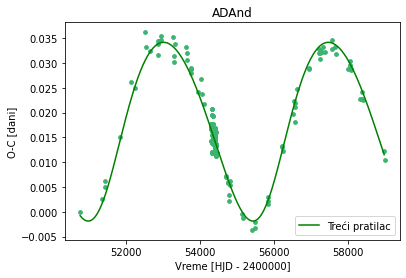

AOCam 12


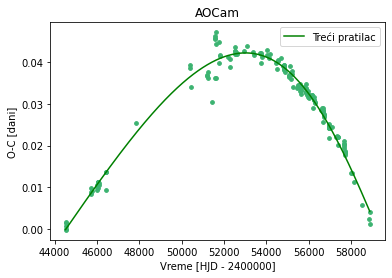

APLeo 15


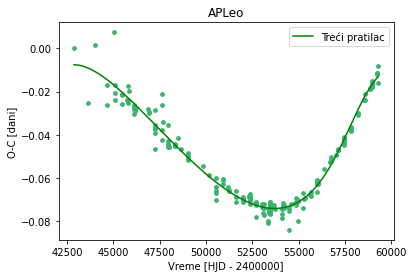

ARLac 18


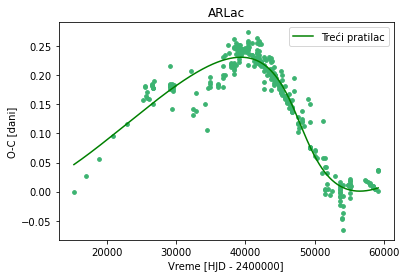

AYVul 23


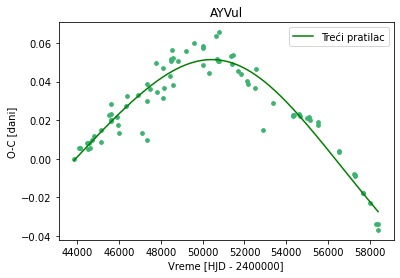

BCHer 25


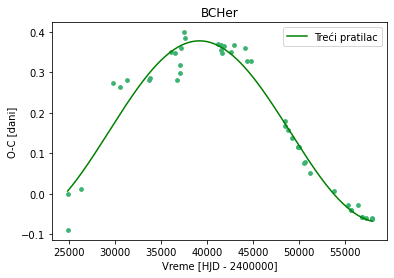

BEVul 28


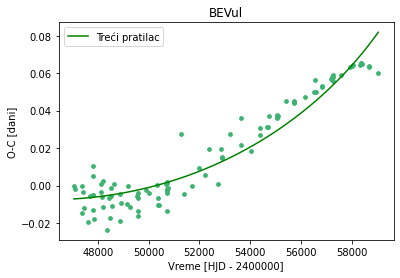

BKVul 30


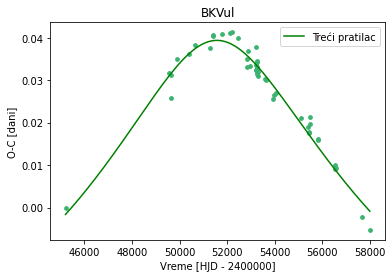

BOGem 32


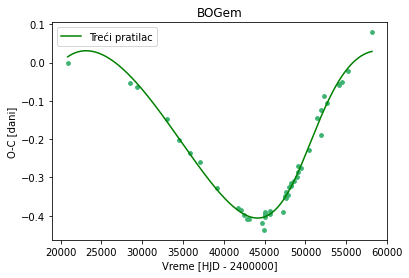

BOPeg 35


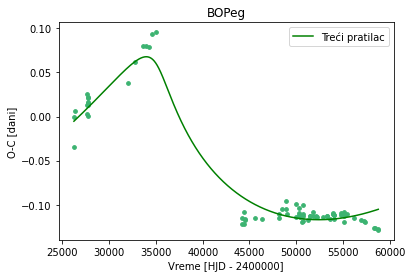

CCHer 40


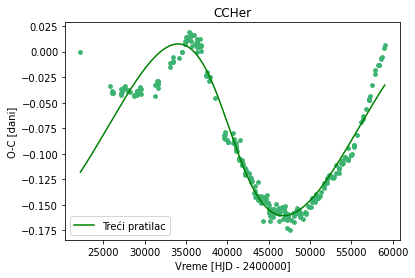

DKPeg 55


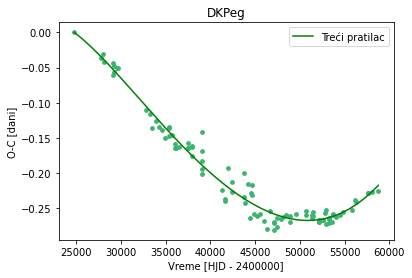

EFDra 62


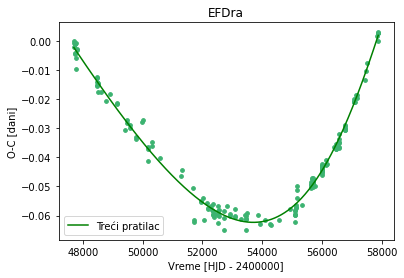

EWLyr 67


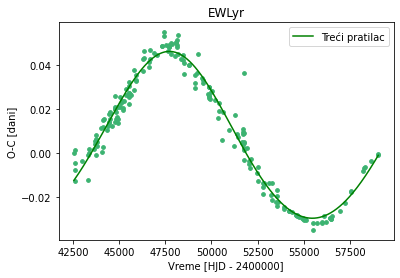

EZHya 70


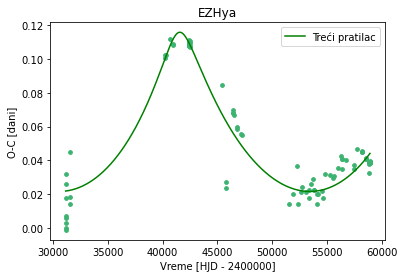

FGHya 72


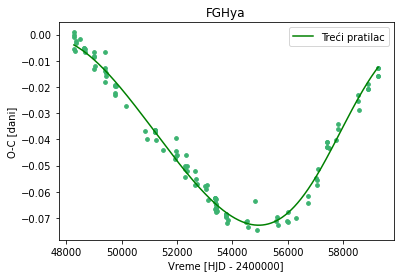

FKOri 74


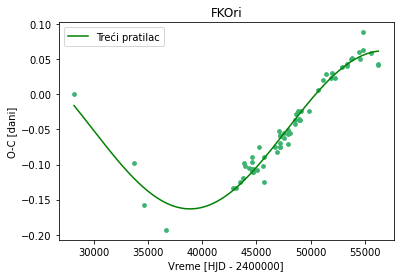

FZOri 78


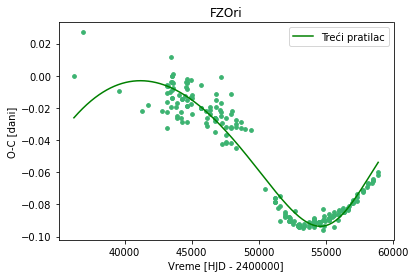

GLHer 82


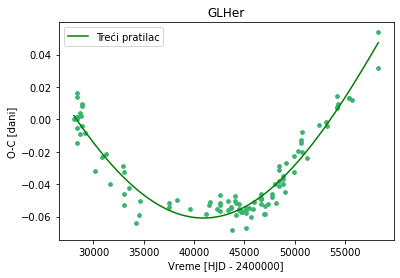

GVLeo 88


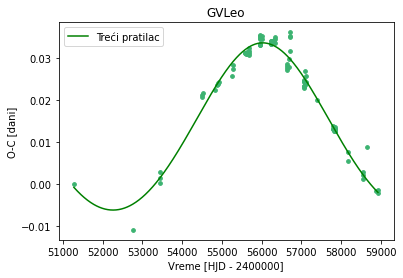

IVCas 96


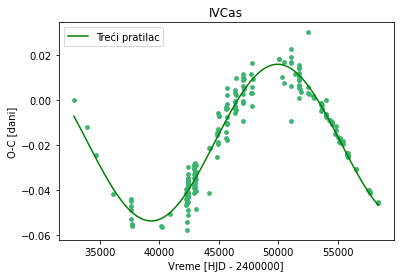

LZLyr 103


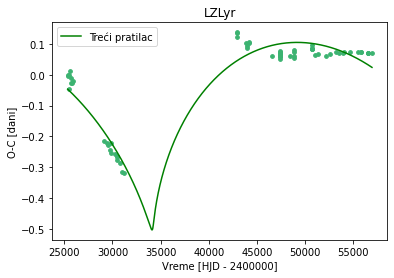

OOAql 105


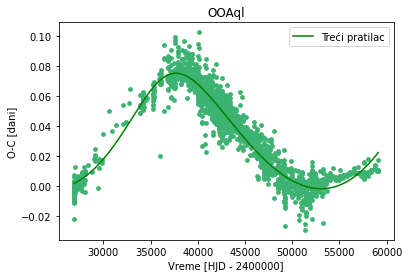

RSSer 113


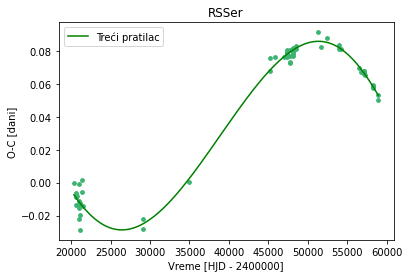

RTLac 116


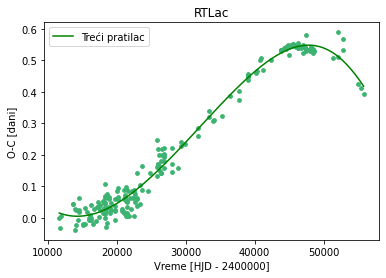

RYAqr 126


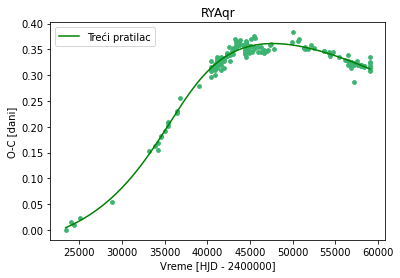

RZAur 129


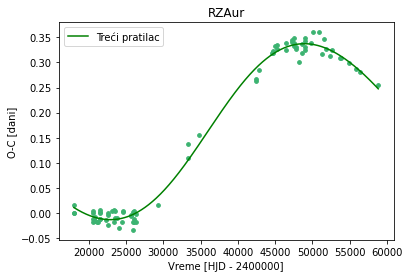

STPer 135


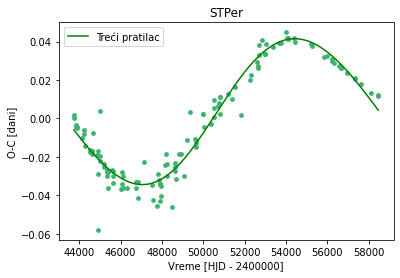

TLMi 147


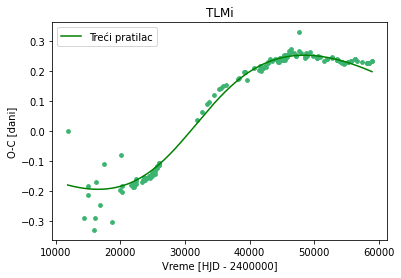

TWLac 157


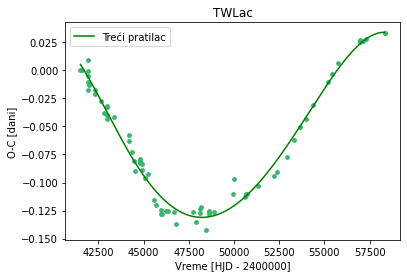

TZEri 166


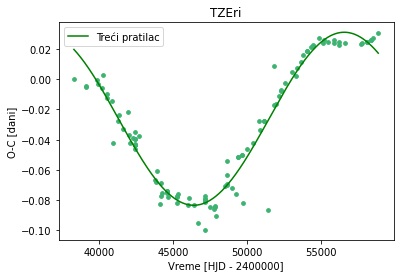

UULeo 171


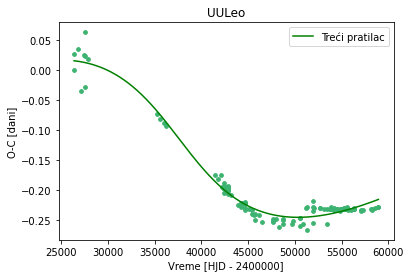

UWCyg 174


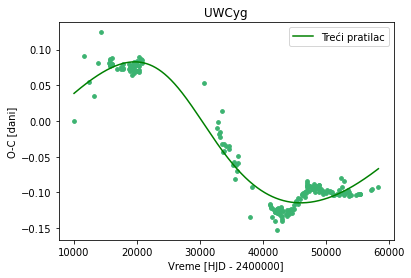

UXHer 177


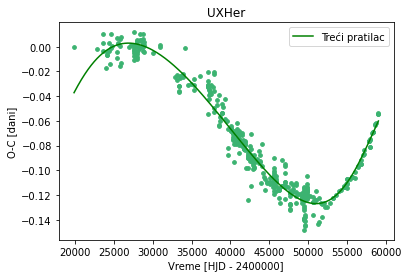

V0346Cyg 180


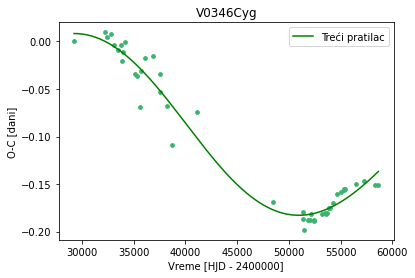

V0410Aur 187


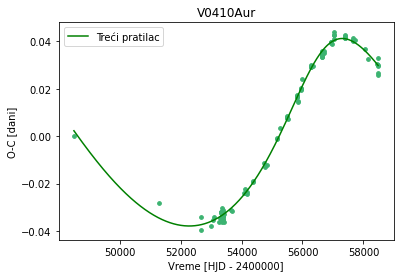

V0482Per 192


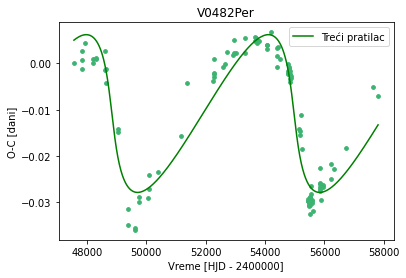

V0995Cyg 208


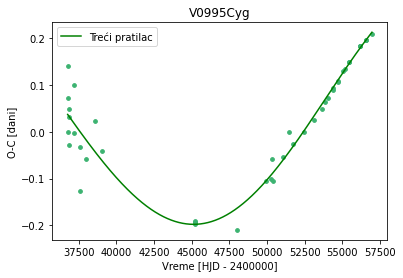

V1042Her 212


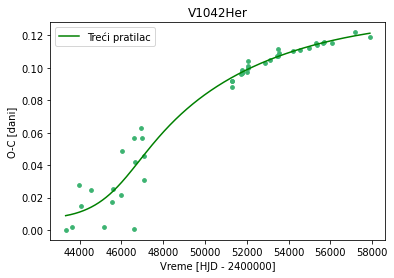

V1100Her 216


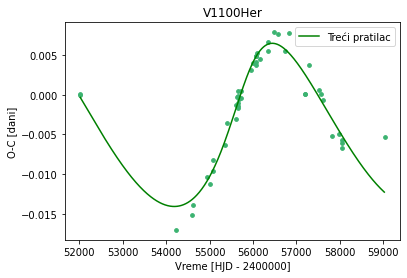

V1139Cas 219


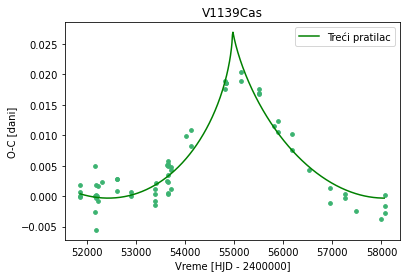

WWDra 233


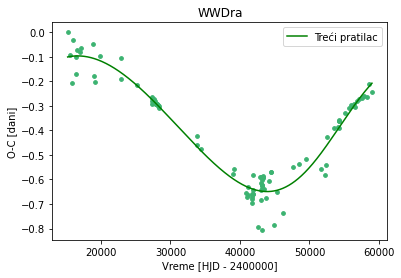

WXAnd 235


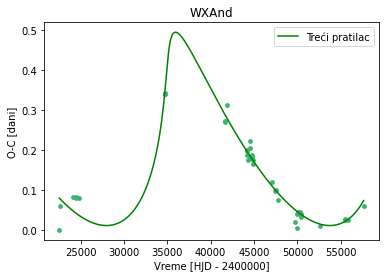

XTri 239


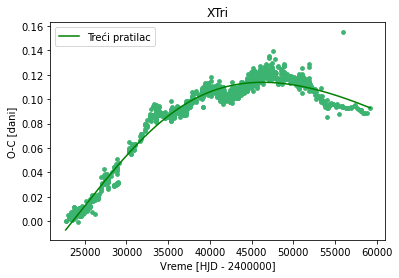

XZPer 247


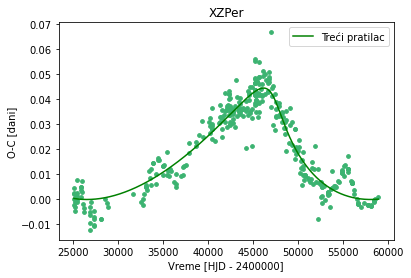

YCyg 250


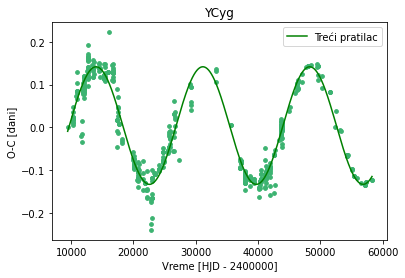

YSex 253


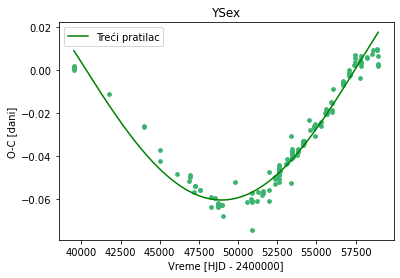

YYCrB 254


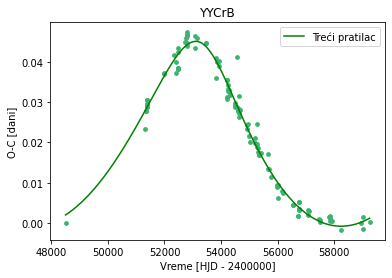

ZPer 256


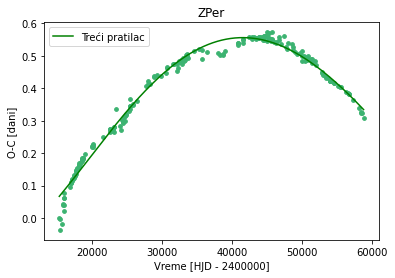

Vreme: 2561.4252960681915 sekundi


In [3]:
start = time.time()
    
T033= []
P33= []
EE= []
ASINI= []
WWW = []
Y=[]
ime1=[]
Masaz = []

T033_e= []
P33_e = []
EE_e = []
ASINI_e= []
WWW_e = []
Y_e=[]
Masaz_e = []
P2 = []


zvezdica = 0
brojac = 0
premalo = 0
Nijetrojni = 0

for j in range(len(name)):

    Pe = P[j]
    ime = name[j]


    data = pd.read_csv('Podaci/'+ime+'.csv', names=['a','b','c','d','e','f','g','h','k'], delimiter = ',')

    t = np.array(data['c'])

    t0 = t[0]

    Epohe = Epoch(t, Pe)
    oc = OC(t,Epohe, Pe)

    if len(t)<40:
        premalo += 1
        continue
    
    #Računanje pretpostavljenog perioda
    frequency, power = LombScargle(t, oc).autopower()
    p = (1/frequency[np.argmax(power)])
    p2=p + p*0.5 
    p1=p - p*0.5


    #Traženje predpostavljene vrednosti za t0 - prolazak kroz perihel
    Emax=t[np.argmax(oc)]
    t01 = Emax - p/4
    t02 = Emax + p/4

    a1 = 149597900 #km, = 1AU
    a2 = 8975872000 #km, = 30AU

    #ppd = Pe - Pe/5
    #ppg = Pe + Pe/5

    granice = [[t01, p1, 0, a1, 0, -0.5], [t02, p2, 0.99, a2, 2*np.pi, 0.5]]

    
    sad, pcov = curve_fit(OC_trece_telo, t, oc, bounds=granice, maxfev=5000)

    t03, P3, e, asini, W, shift = sad
   
    r2z = r2_score(oc, OC_trece_telo(t, t03, P3, e, asini, W, shift))

    if r2z<=0.9:
        Nijetrojni += 1
        continue

    greske, popt_bootstrap = izracunaj_bootstrap_greske(t, oc, granice, N=200)

    t03_err, P3_err, e_err, asini_err, W_err, shift_err = greske
    M3 = izracunaj_masu_treceg_tela(P3, asini)
    
    M3_error = izracunaj_bootstrap_gresku_mase(popt_bootstrap)
    
    zvezdica = zvezdica + 1

    
    P2.append(Pe)
    T033.append(t03)
    P33.append(P3)
    EE.append(e)
    ASINI.append(asini)
    WWW.append(W)
    Y.append(shift)
    ime1.append(ime)
    Masaz.append(M3)

    T033_e.append(t03_err)
    P33_e.append(P3_err)
    EE_e.append(e_err)
    ASINI_e.append(asini_err)
    WWW_e.append(W_err)
    Y_e.append(shift_err)
    Masaz_e.append(M3_error)

    #Plot
    tt=np.arange(t0, t[-1], 10)

    plt.scatter(t, oc, color='mediumseagreen', s=14)
    plt.plot(tt, OC_trece_telo(tt, *sad),color='green',label="Treći pratilac")
    plt.legend()
    plt.xlabel('Vreme [HJD - 2400000]')
    plt.ylabel('O-C [dani]')
    plt.title(ime)
    print(ime, j)

    #plt.savefig(ime+'.eps', format='eps')
    plt.show()

end = time.time()

print("Vreme:", end - start, "sekundi")

In [4]:
print('Ukupno sistema:', len(name))
print('Nije uzrok LiTE:', Nijetrojni)
print('Broj sistema odbačenih jer imaju manje od 40 podataka:', premalo)
print('Broj sistema sa zvezdom:', zvezdica)

Ukupno sistema: 259
Nije uzrok LiTE: 176
Broj sistema odbačenih jer imaju manje od 40 podataka: 34
Broj sistema sa zvezdom: 49


In [5]:
data = {
    'Ime sistema': ime1,
    't03 [HJD]': np.round(T033, 0),
    't03 err [HJD]': np.round(T033_e, 0),
    'P3 [dani]': np.round(P33, 0),
    'P3 err [dani]': np.round(P33_e,0),
    'e': np.round(EE,2),
    'e err': np.round(EE_e,2),
    'asini [AU]': np.round(np.array(ASINI)*6.68e-9, 2),
    'asini err [AU]': np.round(np.array(ASINI_e)*6.68e-9, 2),
    'w [rad]': np.round(WWW,1),
    'w err [rad]': np.round(WWW_e,1),
    'shift': np.round(Y,2),
    'shift_err': np.round(Y_e, 2),
    'M3 [Msun]': np.round(Masaz,2),
    'M3 err [Msun]': np.round(Masaz_e,2),
    'P2 [dani]': np.round(P2, 2)
}

In [6]:
df = pd.DataFrame(data)
df

,Ime sistema,t03 [HJD],t03 err [HJD],P3 [dani],P3 err [dani],e,e err,asini [AU],asini err [AU],w [rad],w err [rad],shift,shift_err,M3 [Msun],M3 err [Msun],P2 [dani]
0,ADAnd,51420.0,0.0,4465.0,25.0,0.19,0.03,3.15,0.05,2.4,0.0,-0.02,0.00,1.32,0.03,0.99
1,AOCam,58817.0,4904.0,33534.0,6853.0,0.25,0.13,8.70,2.49,6.0,1.1,0.01,0.01,0.86,0.18,0.33
2,APLeo,40483.0,1107.0,17699.0,1074.0,0.38,0.11,6.16,0.56,3.5,0.3,0.04,0.00,0.95,0.09,0.43
3,ARLac,47910.0,211.0,50107.0,1801.0,0.50,0.03,22.91,0.48,6.3,0.0,-0.12,0.00,2.27,0.08,1.98
4,AYVul,51484.0,1312.0,43735.0,269.0,0.32,0.14,14.26,2.58,4.9,0.2,0.03,0.02,1.30,0.33,2.41
5,BCHer,37706.0,5332.0,39457.0,5020.0,0.00,0.12,38.73,4.28,4.5,0.8,-0.15,0.02,7.85,1.18,3.09
6,BEVul,61269.0,1130.0,31763.0,5475.0,0.98,0.21,15.03,2.71,4.4,0.5,-0.07,0.02,1.90,0.38,1.55
7,BKVul,51461.0,1371.0,27392.0,4794.0,0.41,0.18,5.46,1.98,4.7,0.7,-0.01,0.01,0.58,0.62,0.45
8,BOGem,49682.0,1839.0,35801.0,3920.0,0.29,0.09,39.30,3.69,2.8,0.6,0.19,0.02,9.33,8.87,4.07
9,BOPeg,35229.0,690.0,47010.0,2435.0,0.70,0.09,17.65,2.53,5.4,0.1,0.02,0.01,1.64,0.33,0.58


## Čuvanje rezultata

In [7]:
d1 = [ime1, T033, T033_e, P33, P33_e, EE, EE_e, ASINI, ASINI_e, WWW, WWW_e, Y, Y_e, Masaz, Masaz_e, P2]


df = pd.DataFrame(data)


export_data = zip_longest(*d1, fillvalue = '')
with open('Rezultati.csv', 'w', encoding="ISO-8859-1", newline='') as myfile:
    wr = csv.writer(myfile)
    wr.writerow(("ime1", "T033", "T033_e", "P33", "P33_e", "EE", "EE_e", "ASINI", "ASINI_e", "WWW", "WWW_e", "Y", "Y_e", "Masaz", "Masaz_e", "P2"))
    wr.writerows(export_data)
myfile.close()